# Statistical Testing: Land vs. Ocean Environmental Variables (Welch's t-test)

**Purpose:** Tests whether environmental variables (MUCAPE, MULCL, RH36mean, LR36) 
differ significantly between land and ocean, across three storm categories 
(OT only, OT + LS, LS only), and separately between LS-only and OT-only events overall.

**Input:** Per-category environmental variable data (land/ocean, 3D), read from 
feather-format files (note: saved with a `.csv` extension by mistake — actual format is feather).

**Method:** Welch's t-test (`scipy.stats.ttest_ind`, `equal_var=False`) applied independently 
to each variable within each category (land vs. ocean), and separately between combined 
LS-only vs. OT-only groups (regardless of land/ocean).

**Output:** 
- `results_df` — per-category, per-variable t-statistics and p-values (land vs. ocean)
- `result_1_df` — LS-only vs. OT-only t-test results across all variables
- A scatter plot of p-values by group/variable, with significance threshold (p = 0.05) marked

In [38]:
from scipy import stats
import pyarrow
import pandas as pd
from pathlib import Path

In [39]:
folders = {"ls_only_land":"1_env_variables_mucape_0_ls_only_land_3d.csv",
          "ls_only_ocean":"1_env_variables_mucape_0_ls_only_ocean_3d.csv",
          "ls_ot_land":"1_env_variables_mucape_0_ls_ot_land_3d.csv",
          "ls_ot_ocean":"1_env_variables_mucape_0_ls_ot_ocean_3d.csv",
          "ot_only_land":"1_env_variables_mucape_0_ot_only_land_3d.csv",
          "ot_only_ocean":"1_env_variables_mucape_0_ot_only_ocean_3d.csv"}


data_dir = Path("/g/data/if69/tp4064/Project_1/categorical_position/dialation_mucape/categorical_position")

data = {name : pd.read_feather(data_dir/file) for name, file in folders.items()}

# accidently I saved with .csv extention but it is a feather file

categories = {
    'OT only' : (data['ot_only_land'], data['ot_only_ocean']),
    'OT + LS' : (data['ls_ot_land'], data['ls_ot_ocean']),
    'LS only' : (data['ls_only_land'], data['ls_only_ocean'])
}

contrast = {
    'land' : (data['ot_only_land'], data['ls_ot_land'], data['ls_only_land']),
    'ocean' : (data['ot_only_ocean'], data['ls_ot_ocean'], data['ls_only_ocean'])
}


In [ ]:
# independent two-sample t-test
# Here, you compare two separate groups (e.g., Men vs. Women).

# Null Hypothesis: The means of both groups are equal in the population. Any observed difference in your sample 
# is just random noise.
# Alternative Hypothesis: The means are actually different. The difference is systematic and not just a fluke.

In [34]:
results = []
list_var = ['MUCAPE','MULCL','RH36mean','LR36']

for group,(land, ocean) in categories.items():

    # print(land['MUCAPE'])
    for v in list_var:
        print(group,v)
        group1 = land[v]
        group2 = ocean[v]
        
        
        t_stat, p_val = stats.ttest_ind(group1, group2, equal_var = False)
        print(group, v, p_val)
        results.append({
            'group': group,
            'variable': v,
            't_stat': t_stat,
            'p_value': p_val,
            'significant': p_val < 0.05
        })

        
        

# results_df = pd.DataFrame(results)
# results_df.to_csv(data_dir/'tttest_results.csv')

OT only MUCAPE
OT only MUCAPE 0.3343791552769235
OT only MULCL
OT only MULCL 0.0
OT only RH36mean
OT only RH36mean 2.4286011846387884e-51
OT only LR36
OT only LR36 2.3021599795153807e-45
OT + LS MUCAPE
OT + LS MUCAPE 4.984050169161453e-219
OT + LS MULCL
OT + LS MULCL 0.0
OT + LS RH36mean
OT + LS RH36mean 0.0
OT + LS LR36
OT + LS LR36 0.0
LS only MUCAPE
LS only MUCAPE 0.0
LS only MULCL
LS only MULCL 0.0
LS only RH36mean
LS only RH36mean 0.0
LS only LR36
LS only LR36 0.0


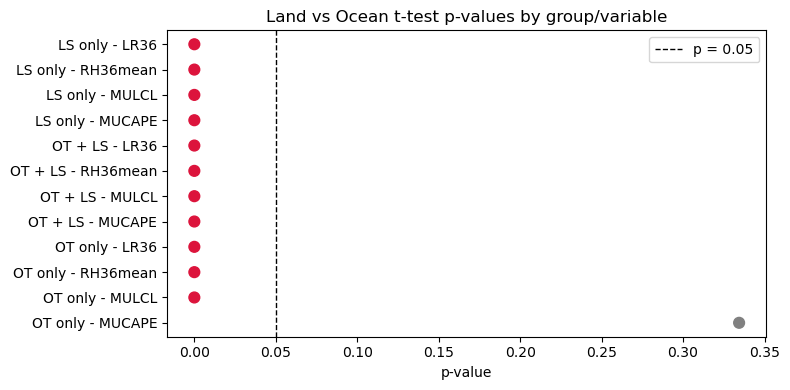

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, max(4, len(results_df) * 0.3)))

results_df['label'] = results_df['group'].astype(str) + ' - ' + results_df['variable']
colors = results_df['significant'].map({True: 'crimson', False: 'gray'})

ax.scatter(results_df['p_value'], results_df['label'], c=colors, s=60, zorder=3)
ax.axvline(0.05, color='black', linestyle='--', linewidth=1, label='p = 0.05')

ax.set_xlabel('p-value')
ax.set_title('Land vs Ocean t-test p-values by group/variable')
ax.legend()

plt.tight_layout()
# plt.savefig('pvalue_plot.png', dpi=150)
plt.show()

In [40]:
#doing ttest land vs ocean with whole categories for every variables
ls_only= pd.concat([data['ls_only_land'],  data['ls_only_ocean']],axis = 0, ignore_index = True)
ot_only = pd.concat([data['ot_only_land'],  data['ot_only_ocean']],axis = 0, ignore_index = True)

result_1 = []

for v in list_var:
    

    t_stat, p_value = stats.ttest_ind(ls_only[v], ot_only[v], equal_var = False)

    result_1.append({
        'group':'ls_only_ot_only',
        'variable' : v,
        't_stat' : t_stat,
        'p_value' : p_value,
        'significant': p_value<0.05
        
    })

result_1_df = pd.DataFrame(result_1)
# result_1_df.to_csv(data_dir/'stats_tttest_land_ocean.csv')
    
    

In [41]:
result_1_df

,group,variable,t_stat,p_value,significant
0,ls_only_ot_only,MUCAPE,199.339597,0.0,True
1,ls_only_ot_only,MULCL,1327.346817,0.0,True
2,ls_only_ot_only,RH36mean,-1217.792355,0.0,True
3,ls_only_ot_only,LR36,961.934236,0.0,True
